In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
num_cpus = 10

In [3]:
import os
os.environ["POLARS_MAX_THREADS"] = f"{num_cpus}"

In [6]:
import polars as pl
from lib import read_chain_file, chain_to_scheme, convert_cooler
import bioframe
import cooler
from cooler.create import aggregate_records, create_cooler
from cytoolz import compose

# Define resolution and file paths
resolution = 10000
path = "/home/agalicina/DROSOPHILA/HiCLift/data/"
input_file = path + "dm3ToDm6.over.chain.gz"

ImportError: cannot import name 'read_chain_file' from 'lib' (/Users/egorpitikov/Documents/pets/liftover_2d/lib/__init__.py)

In [5]:
# Read chain file
chains_df, blocks_df = read_chain_file(input_file)

# Load source and target cooler files
input_cooler_file = f'./data/adult_CNS.dm3.mapq_30.100.mcool::/resolutions/{resolution}'
clr = cooler.Cooler(input_cooler_file)

bins_source = clr.bins()[:]

reference_file = f'./data/adult_CNS.dm6.mapq_30.100.mcool::/resolutions/{resolution}'
clr_target = cooler.Cooler(reference_file)
bins_target = clr_target.bins()[:]

In [6]:
# Generate conversion scheme
conversion_scheme, conversion_scheme_full = chain_to_scheme(bins_source, bins_target, chains_df, blocks_df)

In [7]:
# Convert cooler file
chunksize = 1_000_000

In [8]:
chunks_converted_no_cvd = convert_cooler(clr, conversion_scheme, chunksize=chunksize, mode='resample')

In [9]:
output_cooler = f"./output/output_upd.dm3-to-dm6.{resolution}.full.resample.no-cvd.cool"

# Create new cooler file
aggregate = aggregate_records(agg={'count': 'sum'}, count=False, sort=False)
pipeline = compose(aggregate)

create_cooler(
    output_cooler,
    bins_target,
    map(pipeline, chunks_converted_no_cvd),
    mergebuf=chunksize,
    ordered=False,
    mode="w",
)


29it [01:27,  3.01s/it]


#### The sampling takes into account distance between resulting bins: 

In [12]:
import bioframe
view_df = bioframe.make_viewframe( clr.chromsizes )

In [13]:
# Calculate scaling:
from cooltools import expected_cis, expected_trans

cvd = expected_cis(
    clr=clr,
    view_df=view_df,
    smooth=True,
    aggregate_smoothed=True,
    nproc=num_cpus 
)

cvd = cvd.groupby(['region1']).get_group(view_df.chrom[0])
cvd_values = cvd.set_index('dist')['balanced.avg.smoothed.agg']

cvd_values[0] = 1.0 # TODO: make more clever by interpolating the zero value to make it more realistic
cvd_values[1] = 1.0

INFO:root:creating a Pool of 10 workers
/home/agalicina/anaconda3/envs/HiCLift/lib/python3.9/multiprocessing/popen_fork.py:66: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is because you are using the
multiprocessing module on Linux, which uses fork() by default. This will be
fixed in Python 3.14. Until then, you want to use the "spawn" context instead.

See https://docs.pola.rs/user-guide/misc/multiprocessing/ for details.

  self.pid = os.fork()
/home/agalicina/soft/cooltools/cooltools/api/expected.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))
/tmp

In [14]:
cvd_trans = expected_trans(
    clr=clr,
    view_df=view_df,
    nproc=num_cpus 
)
cvd_value_trans = cvd_trans.set_index(['region1', 'region2'])['balanced.avg'].mean()

INFO:root:creating a Pool of 10 workers
/home/agalicina/anaconda3/envs/HiCLift/lib/python3.9/multiprocessing/popen_fork.py:66: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is because you are using the
multiprocessing module on Linux, which uses fork() by default. This will be
fixed in Python 3.14. Until then, you want to use the "spawn" context instead.

See https://docs.pola.rs/user-guide/misc/multiprocessing/ for details.

  self.pid = os.fork()


In [15]:
# Generate conversion scheme
conversion_scheme, conversion_scheme_full = chain_to_scheme(bins_source, bins_target, chains_df, blocks_df, return_chroms=True)

In [16]:
chunks_converted_with_cvd = convert_cooler(clr, conversion_scheme, chunksize=chunksize, cvd_norm=(cvd_values.fillna(1), cvd_value_trans), mode='resample')

In [17]:
output_cooler = f"./output/output_upd.dm3-to-dm6.{resolution}.full.resample.with-cvd.cool"

# Create new cooler file
aggregate = aggregate_records(agg={'count': 'sum'}, count=False, sort=False)
pipeline = compose(aggregate)

create_cooler(
    output_cooler,
    bins_target,
    map(pipeline, chunks_converted_with_cvd),
    mergebuf=chunksize,
    ordered=False,
    mode="w",
)


29it [01:41,  3.49s/it]


### Test both options: 

#### From dm3 (worse) to dm6 (better):

In [18]:
query='chr3L'

In [19]:
import cooler
import pandas as pd

In [20]:
resolution = 10000

In [21]:
file_cooler_no_cvd = f"./output/output_upd.dm3-to-dm6.{resolution}.full.resample.no-cvd.cool"

clr_no_cvd = cooler.Cooler(file_cooler_no_cvd)
fetcher_no_cvd = clr_no_cvd.matrix(as_pixels=True, balance=False, join=True)

mtx_cooler_no_cvd = fetcher_no_cvd.fetch(query)

In [22]:
file_cooler_with_cvd = f"./output/output_upd.dm3-to-dm6.{resolution}.full.resample.with-cvd.cool"

clr_with_cvd = cooler.Cooler(file_cooler_with_cvd)
fetcher_with_cvd = clr_with_cvd.matrix(as_pixels=True, balance=False, join=True)

mtx_cooler_with_cvd = fetcher_with_cvd.fetch(query)

In [25]:
reference_file = f"../distiller-nf/results_metaloops/coolers_library_group/adult_CNS.dm6.mapq_30.100.mcool::/resolutions/{resolution}"
clr_ref = cooler.Cooler(reference_file)

fetcher_ref = clr_ref.matrix(as_pixels=True, balance=False, join=True)
mtx_reference = fetcher_ref.fetch(query)

In [26]:
mtx_merged = pd.merge( mtx_cooler_no_cvd, mtx_cooler_with_cvd, on=['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2'], suffixes=['', '_with_cvd'])
mtx_merged = pd.merge( mtx_merged, mtx_reference, on=['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2'], suffixes=['_no_cvd', '_ref'])

In [27]:
mtx_merged.query('count_no_cvd!=count_ref')

,chrom1,start1,end1,chrom2,start2,end2,count_no_cvd,count_with_cvd,count_ref
62,chr3L,10000,20000,chr3L,5580000,5590000,0,1,1
63,chr3L,10000,20000,chr3L,6230000,6240000,0,0,1
64,chr3L,10000,20000,chr3L,6370000,6380000,0,0,1
66,chr3L,10000,20000,chr3L,6750000,6760000,0,1,1
67,chr3L,10000,20000,chr3L,6930000,6940000,0,1,1
...,...,...,...,...,...,...,...,...,...
2543826,chr3L,24520000,24530000,chr3L,24530000,24540000,2347,2432,410
2543827,chr3L,24520000,24530000,chr3L,24540000,24550000,287,15,17
2543828,chr3L,24530000,24540000,chr3L,24530000,24540000,3122,3166,7362
2543829,chr3L,24530000,24540000,chr3L,24540000,24550000,2532,2667,1409


<Axes: xlabel='count_no_cvd', ylabel='count_ref'>

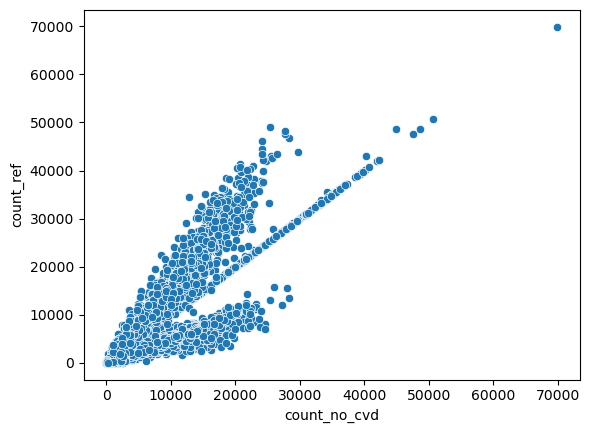

In [28]:
import seaborn as sns
sns.scatterplot(x='count_no_cvd', y='count_ref', data=mtx_merged)

<Axes: xlabel='count_with_cvd', ylabel='count_no_cvd'>

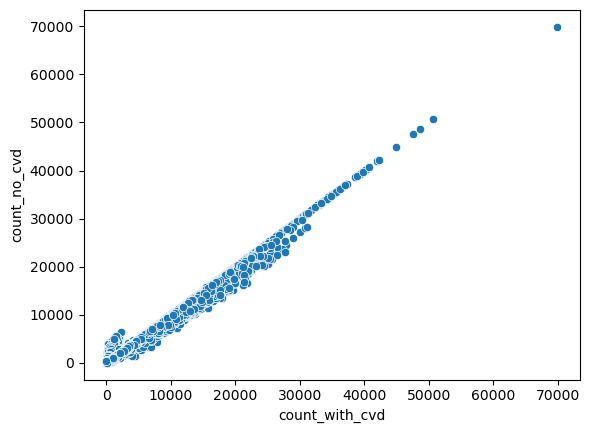

In [29]:
import seaborn as sns
sns.scatterplot(x='count_with_cvd', y='count_no_cvd', data=mtx_merged)

<Axes: xlabel='count_with_cvd', ylabel='count_ref'>

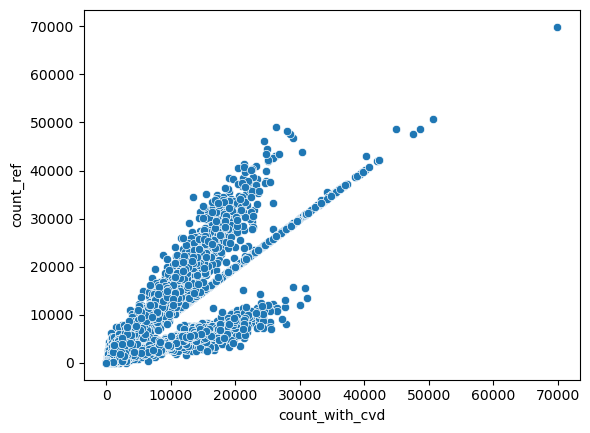

In [30]:
import seaborn as sns
sns.scatterplot(x='count_with_cvd', y='count_ref', data=mtx_merged)

In [38]:
v1 = mtx_merged['count_with_cvd']-mtx_merged['count_ref']
v2 = mtx_merged['count_no_cvd']-mtx_merged['count_ref']
v_ref = mtx_merged['count_ref']

In [47]:
import numpy as np
import matplotlib.pyplot as plt

Text(0.5, 0, 'expected count per pixel')

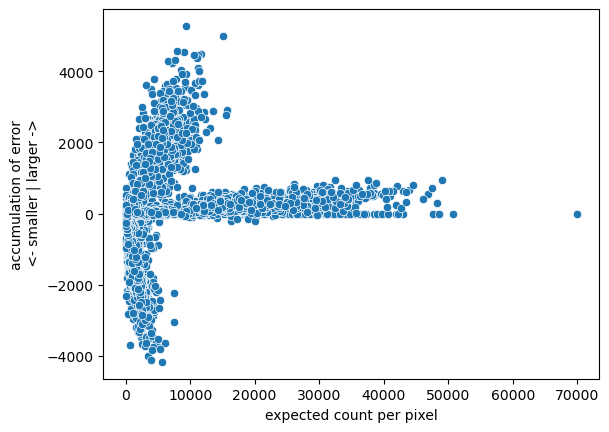

In [50]:
sns.scatterplot(y=v1-v2, x=v_ref)
plt.ylabel('accumulation of error\n <- smaller | larger ->')
plt.xlabel('expected count per pixel')

<Axes: xlabel='count_ref', ylabel='None'>

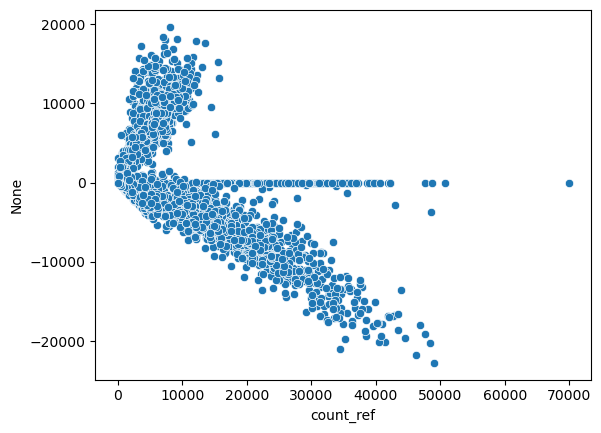

In [51]:
sns.scatterplot(y=v1, x=v_ref)

In [31]:
mtx_merged.columns

Index(['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2', 'count_no_cvd',
       'count_with_cvd', 'count_ref'],
      dtype='object')

In [32]:
mtx_merged[['count_no_cvd', 'count_with_cvd', 'count_ref']].corr()

,count_no_cvd,count_with_cvd,count_ref
count_no_cvd,1.000000,0.993753,0.910871
count_with_cvd,0.993753,1.000000,0.890781
count_ref,0.910871,0.890781,1.000000


In [33]:
mtx_merged[['count_no_cvd', 'count_with_cvd', 'count_ref']].corr(method='spearman')

,count_no_cvd,count_with_cvd,count_ref
count_no_cvd,1.000000,0.82915,0.804104
count_with_cvd,0.829150,1.00000,0.804170
count_ref,0.804104,0.80417,1.000000


#### From dm6 (better) to dm3 (worse):

<Axes: xlabel='count_no_cvd', ylabel='count_ref'>

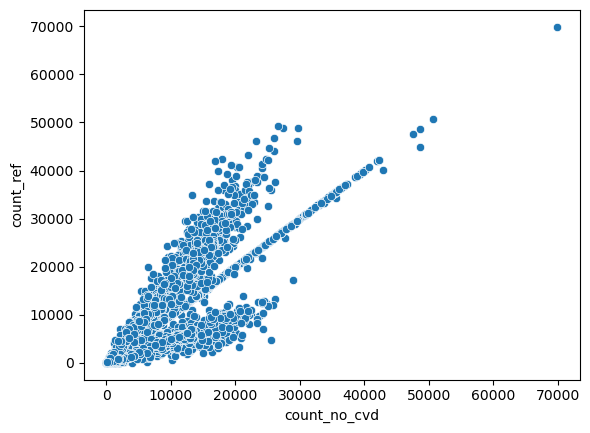

In [346]:
import seaborn as sns
sns.scatterplot(x='count_no_cvd', y='count_ref', data=mtx_merged)

<Axes: xlabel='count_with_cvd', ylabel='count_no_cvd'>

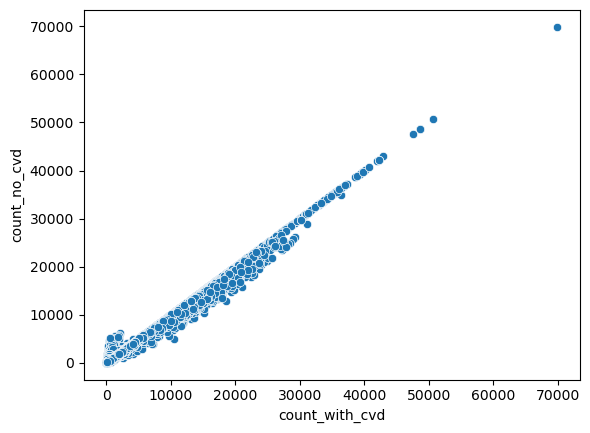

In [350]:
import seaborn as sns
sns.scatterplot(x='count_with_cvd', y='count_no_cvd', data=mtx_merged)

<Axes: xlabel='count_with_cvd', ylabel='count_ref'>

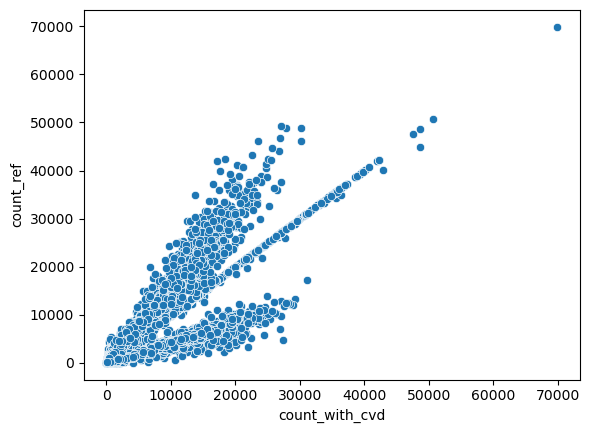

In [347]:
import seaborn as sns
sns.scatterplot(x='count_with_cvd', y='count_ref', data=mtx_merged)

In [348]:
mtx_merged.columns

Index(['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2', 'count_no_cvd',
       'count_with_cvd', 'count_ref'],
      dtype='object')

In [349]:
mtx_merged[['count_no_cvd', 'count_with_cvd', 'count_ref']].corr()

,count_no_cvd,count_with_cvd,count_ref
count_no_cvd,1.000000,0.993651,0.908594
count_with_cvd,0.993651,1.000000,0.888407
count_ref,0.908594,0.888407,1.000000


In [351]:
mtx_merged[['count_no_cvd', 'count_with_cvd', 'count_ref']].corr(method='spearman')

,count_no_cvd,count_with_cvd,count_ref
count_no_cvd,1.000000,0.828842,0.802386
count_with_cvd,0.828842,1.000000,0.802247
count_ref,0.802386,0.802247,1.000000
